In [2]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models
from torchvision.models import EfficientNet_B5_Weights

# โหลดโมเดล EfficientNetB5
model = models.efficientnet_b5(weights=EfficientNet_B5_Weights.DEFAULT)  # สร้างโมเดลเปล่า
num_classes = 3  # ปรับตามจำนวนคลาสของคุณ
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)

# โหลดน้ำหนักที่เทรนมาแล้ว
model.load_state_dict(torch.load("efficientnet_model_3d_preprocess_2.pth", map_location=torch.device("cpu")))
model.eval()

# เลือก Layer เป้าหมาย (Conv Layer สุดท้ายของ EfficientNetB5)
target_layer = model.features[-1]


C:\Users\tata_\AppData\Local\Temp\ipykernel_28152\1279420887.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("efficientnet_model_3d_pre

In [3]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.feature_map = None

        # Hook function
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.feature_map = output  # เก็บ Feature Map ตอน forward pass

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]  # เก็บ Gradient ตอน backward pass

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax().item()  # ใช้คลาสที่โมเดลทำนาย

        # คำนวณ Gradient
        one_hot = torch.zeros_like(output)
        one_hot[0, class_idx] = 1
        output.backward(gradient=one_hot)

        # คำนวณ Weight ของแต่ละ Feature Map
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.feature_map).sum(dim=1, keepdim=True)

        # Normalization ให้อยู่ในช่วง 0-1
        cam = F.relu(cam)  # เอาค่าติดลบออก
        cam = cam - cam.min()
        cam = cam / cam.max()
        return cam.squeeze().cpu().detach().numpy()

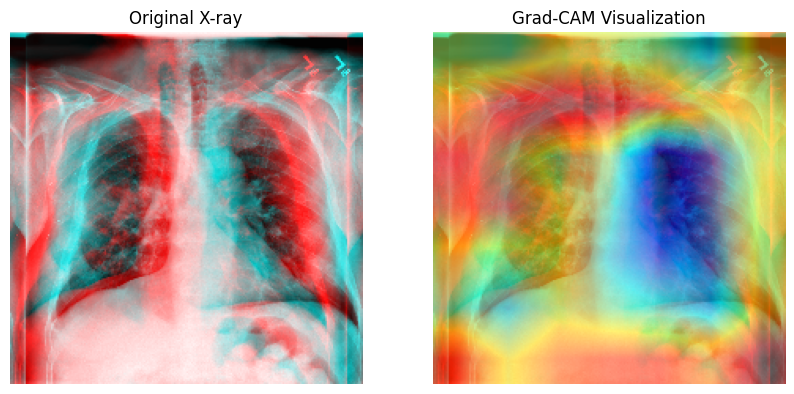

: 

In [ ]:
def apply_heatmap(image, heatmap, alpha=0.5):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))  # ปรับขนาดให้ตรงกับภาพ X-ray
    heatmap = np.uint8(255 * heatmap)  # แปลงค่าเป็น 0-255
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # ใส่สีแบบ JET

    overlay = cv2.addWeighted(image, 1 - alpha, heatmap, alpha, 0)  # ผสมภาพ X-ray กับ heatmap
    return overlay

def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),  
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tensor = transform(image).unsqueeze(0)  # เพิ่ม batch dimension
    return image, image_tensor

def show_gradcam(image_path):
    image, input_tensor = preprocess_image(image_path)

    grad_cam = GradCAM(model, target_layer)
    heatmap = grad_cam.generate_heatmap(input_tensor)

    overlay = apply_heatmap(image, heatmap)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original X-ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Grad-CAM Visualization")
    plt.axis("off")

    plt.show()

# 🔥 ใส่ภาพ X-ray ของคุณตรงนี้
show_gradcam(r"D:\Coding\Project\3D_Preprocess\pneumonia\stereo_processed_00000165_001.png")
